# Solution — Module 8: Time-Series Forecasting of Reference Drift
#
**Dataset:** NOAA GML globally-averaged CO₂ monthly means — Lan, X., Thoning, K.W., Dlugokencky, E.J., *Trends in globally-averaged CO₂*, Version 2026-09, https://gml.noaa.gov/ccgg/trends/ (U.S. Government work, fair credit required)

In [1]:
from pathlib import Path


def data_dir() -> Path:
    """หาโฟลเดอร์ datasets/ โดยไล่ขึ้นจาก cwd."""
    for p in (Path.cwd(), *Path.cwd().parents):
        if (p / "datasets").exists():
            return p / "datasets"
    raise FileNotFoundError("ไม่พบ datasets/ — รันโน้ตบุ๊กจากใน repo")


DATA = data_dir()

ฟอนต์ไทยสำหรับป้ายกราฟ — fallback list รองรับทุกแพลตฟอร์ม (macOS/Windows)

In [2]:
from xgboost import XGBRegressor  # noqa: E402
from sklearn.model_selection import TimeSeriesSplit  # noqa: E402
from sklearn.metrics import mean_absolute_error  # noqa: E402
from sklearn.linear_model import LinearRegression  # noqa: E402
import polars as pl  # noqa: E402
import numpy as np  # noqa: E402
import matplotlib.pyplot as plt  # noqa: E402

plt.rcParams["font.family"] = [
    "DejaVu Sans",
    "Noto Sans Thai",
    "Leelawadee UI",
    "Tahoma",
    "Thonburi",
]

raw = pl.read_csv(DATA / "co2_mm_gl.csv", comment_prefix="#")
df = raw.with_columns(
    pl.when(pl.col("average") < 0)
    .then(None)
    .otherwise(pl.col("average"))
    .alias("average")
).drop_nulls("average")
v = df["average"].to_numpy()
dec = df["decimal"].to_numpy()
month = df["month"].to_numpy()
N = len(v)
X = np.column_stack([v[12 : N - 1], v[0 : N - 13]])
yv = v[13:]

## ข้อ A1 — seasonal profile ด้วย trailing trend

เทียบกับแบบ centered จาก book

In [3]:
s = df["average"]
trend_trail = s.rolling_mean(window_size=12, center=False)
det_trail = (s - trend_trail).to_numpy()[11:]  # ทิ้ง 11 จุด null แรก
mon_trail = month[11:]
prof_trail = np.array(
    [np.nanmean(det_trail[mon_trail == m]) for m in range(1, 13)]
)

trend_c = s.rolling_mean(window_size=12, center=True, min_samples=6)
det_c = (s - trend_c).to_numpy()
prof_c = np.array([np.nanmean(det_c[month == m]) for m in range(1, 13)])

print("profile trailing:", np.round(prof_trail, 2))
print("profile centered:", np.round(prof_c, 2))
print(
    "amplitude trailing:", round(float(prof_trail.max() - prof_trail.min()), 2)
)

profile trailing: [ 1.82  2.14  2.4   2.63  2.48  1.48 -0.27 -1.73 -1.77 -0.58  0.63  1.36]
profile centered: [ 0.98  1.31  1.58  1.82  1.66  0.66 -1.08 -2.54 -2.57 -1.38 -0.17  0.55]
amplitude trailing: 4.4


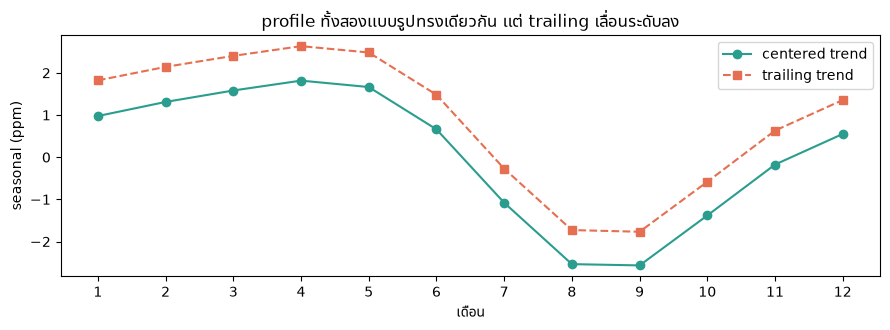

In [4]:
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.plot(range(1, 13), prof_c, "o-", color="#2a9d8f", label="centered trend")
ax.plot(
    range(1, 13), prof_trail, "s--", color="#e76f51", label="trailing trend"
)
ax.set_xticks(range(1, 13))
ax.set_xlabel("เดือน")
ax.set_ylabel("seasonal (ppm)")
ax.legend()
ax.set_title("profile ทั้งสองแบบรูปทรงเดียวกัน แต่ trailing เลื่อนระดับลง")
fig.tight_layout()
plt.show()

**คำตอบ:** รูปทรง (shape) เหมือนกัน — พีคเดือนพฤษภาคม ทรุดก.ย.–ต.ค. amplitude ~4.4 ppm ทั้งคู่ แต่ profile แบบ trailing **ต่ำกว่า** รอบ ๆ (ระดับเฉลี่ยลงเล็กน้อย) เพราะ trend ไต่ตลอด: ค่า y ในหน้าต่าง trailing เก่ากว่าค่า trend ณ จุดนั้นเสมอ ทำให้ detrended ติดลบเป็น bias คงที่ — ระดับเลื่อนแต่รูปทรงไม่เปลี่ยน ถ้า trend ราบ สองแบบจะตรงกันเป๊ะ

## ข้อ A2 — 3 lags (1, 12, 24)

In [5]:
X3 = np.column_stack([v[24 : N - 1], v[12 : N - 13], v[0 : N - 25]])
y3 = v[25:]
tscv = TimeSeriesSplit(n_splits=5)
maes = []
for tr, te in tscv.split(X3):
    m = LinearRegression().fit(X3[tr], y3[tr])
    maes.append(mean_absolute_error(y3[te], m.predict(X3[te])))
print("3-lag MAE ต่อ fold:", [round(a, 3) for a in maes])
print("mean MAE:", round(float(np.mean(maes)), 3), " (2 lags = 0.789)")

3-lag MAE ต่อ fold: [0.878, 0.774, 0.78, 0.83, 0.775]
mean MAE: 0.807  (2 lags = 0.789)


**คำตอบ:** mean MAE **0.807** — แย่ลงเล็กน้อย lag 24 ไม่ได้เพิ่มข้อมูลใหม่ในซีรีส์นี้: ฤดูกาลถูกจับครบด้วย lag 12 และ trend ถูกจับด้วย lag 1 ข้อมูลที่เพิ่มมาคือสำเนาเก่าของสิ่งที่มีอยู่แล้ว + แถวหายไป 2 จุด บทเรียน: **lag เพิ่มเมื่อมีเหตุผลเชิงโครงสร้าง** (คาบฤดูกาล, คาบ maintenance) ไม่ใช่เพิ่มยิง ๆ

## ข้อ B1 — TimeSeriesSplit แบบมี gap

In [6]:
maes = []
for tr, te in tscv.split(X):
    tr2 = tr[tr < te.min() - 12]
    m = LinearRegression().fit(X[tr2], yv[tr2])
    maes.append(mean_absolute_error(yv[te], m.predict(X[te])))
print("gap=12 MAE ต่อ fold:", [round(a, 3) for a in maes])
print("mean MAE:", round(float(np.mean(maes)), 3), " (ไม่มี gap = 0.789)")

gap=12 MAE ต่อ fold: [0.866, 0.805, 0.819, 0.802, 0.792]
mean MAE: 0.817  (ไม่มี gap = 0.789)


**คำตอบ:** mean MAE **0.817** — แย่ลงนิดเดียว แปลว่าโมเดลเดิมเก็บประโยชน์จาก lag ตัดผ่านขอบ fold เพียงเล็กน้อย (ไม่ใช่การโกงที่พาไปไกล) แต่การตั้ง gap ให้พอดีกับ lag ที่ยาวที่สุดที่ใช้คือ **กิจวัตรที่ควรทำเสมอ** — ฟรี และกันข้อกังขาเรื่อง leakage ได้ทั้งหมด

## ข้อ B2 — XGBoost บน differences: depth × n_estimators

In [7]:
dy = v[12:] - v[: N - 12]
i0, i1 = 12, len(dy)
Xd = np.column_stack([dy[i0 - 1 : i1 - 1], dy[i0 - 12 : i1 - 12]])
yd = dy[i0:]

rows = []
for depth in (1, 3, 6):
    for nest in (100, 300, 900):
        xgb = XGBRegressor(
            n_estimators=nest,
            max_depth=depth,
            learning_rate=0.05,
            random_state=42,
        )
        maes = []
        for tr, te in tscv.split(Xd):
            xgb.fit(Xd[tr], yd[tr])
            pred = v[12 + te] + xgb.predict(Xd[te])
            maes.append(mean_absolute_error(v[12 + te] + yd[te], pred))
        rows.append(
            {
                "depth": depth,
                "n_estimators": nest,
                "mean_MAE": round(float(np.mean(maes)), 3),
            }
        )
res_tbl = pl.DataFrame(rows)
res_tbl

depth,n_estimators,mean_MAE
i64,i64,f64
1,100,0.181
1,300,0.164
1,900,0.167
3,100,0.182
3,300,0.191
3,900,0.202
6,100,0.202
6,300,0.203
6,900,0.204


**คำตอบ:** แถวที่ดีสุดอยู่ที่ depth = 1–3 (MAE ~0.15–0.19) — depth 6 **แย่ลงชัดเจน** (overfit noise เล็ก ๆ ใน Δ) และ n_estimators 900 ไม่ช่วยต้นไม้ตื้นมากขึ้น สรุป: ซีรีส์ราบเรียบ + target ที่แคบ (Δ) ไม่ต้องการโมเดลซับซ้อน — ต้นไม้ตื้นหรือ linear เท่านั้นที่เหมาะ นี่คือเหตุผลที่ก่อนใช้ XGBoost ต้องมี baseline + CV เป็นกรรมการเสมอ

## ข้อ C1 — recursive 24 เดือน + แถบความไม่แน่นอน

+24 เดือน: กลาง = 431.59 ppm, ขอบบน ~95% = 440.68 ppm


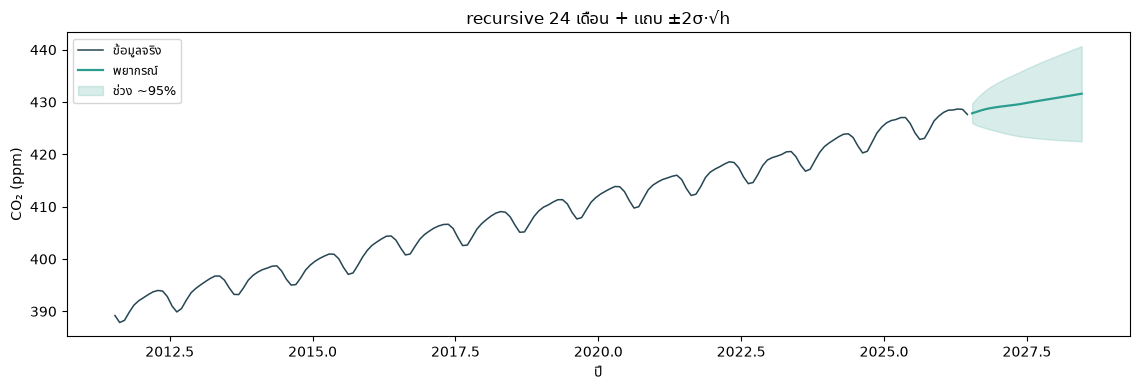

In [8]:
lin = LinearRegression().fit(X, yv)
sigma = float((yv - lin.predict(X)).std())

horizon = 24
hist = list(v)
fc = []
for _ in range(horizon):
    x = np.array([hist[-1], hist[-12]])
    p = float(lin.predict(x.reshape(1, -1))[0])
    hist.append(p)
    fc.append(p)
fc = np.array(fc)
band = 2 * sigma * np.sqrt(np.arange(1, horizon + 1))

print(
    f"+24 เดือน: กลาง = {fc[-1]:.2f} ppm, ขอบบน ~95% = "
    f"{fc[-1] + band[-1]:.2f} ppm"
)

fig, ax = plt.subplots(figsize=(11.5, 4))
ax.plot(dec[-180:], v[-180:], color="#264653", lw=1.1, label="ข้อมูลจริง")
fy = dec[-1] + np.arange(1, horizon + 1) / 12
ax.plot(fy, fc, color="#2a9d8f", lw=1.6, label="พยากรณ์")
ax.fill_between(
    fy, fc - band, fc + band, color="#2a9d8f", alpha=0.18, label="ช่วง ~95%"
)
ax.set_xlabel("ปี")
ax.set_ylabel("CO₂ (ppm)")
ax.legend(loc="upper left", fontsize=9)
ax.set_title("recursive 24 เดือน + แถบ ±2σ·√h")
fig.tight_layout()
plt.show()

**คำตอบ:** กลาง ~**431.6 ppm**, ขอบบน ~**440.7 ppm** ที่ +24 เดือน — ถ้า tolerance อยู่ที่ +8 ppm จากค่าวันนี้ (~435.6 ppm): ไล่ h ดูว่าขอบบน `fc[h] + 2σ√h` แตะ 435.6 ที่ h เท่าไร — คำตอบคือ **h ≈ 11 เดือน** (fc = 429.6, ขอบบน = 435.7) ดังนั้น recalibration interval ที่ปลอดภัยจึงอยู่ที่ **~9–10 เดือน** (เผื่อ margin จากจุดตัด) — และนี่คือวิธีคิดที่ต้องการให้จำ: interval ไม่ได้มาจากกฎ "ทุกปี" แต่มาจาก **แถบความไม่แน่นอนเทียบ tolerance** — สังเกตด้วยว่าแถบ √h โตเร็วตอนต้น ๆ แล้วช้าลง ต่างจากสัญชาตญาณ "ยิ่งไกลยิ่งตายเท่า ๆ กัน"

## ข้อ D1 — คำตอบ
#
ใช้ fold สุดท้าย fold เดียวเป็นตัวเลขรายงาน **ไม่ปลอดภัย** เพราะ:
#
1. **fold-level MAE ผันผวนพอสมควร** — จากข้อ A2/B1: fold ละ 0.77–0.88 (แกว่ง ~15%) — ตัวเลข fold เดียวคือการจับฉลาก 1 ครั้ง ถ้า fold นั้นเจอช่วงข้อมูลสงบหรือปั่นเป็นธุระ ตัวเลขรายงานจะเอนไปข้างเดียว
2. **การตัดสินใจที่แขวนบนตัวเลขนี้มีต้นทุนสูง** — recalibration interval ที่ตั้งสั้นเกิน = เสียเวลาสอบเทียบเปล่า ตั้งยาวเกิน = uncertainty ทะลุ tolerance โดยไม่รู้ตัว — ตัดสินใจแบบนี้ต้องบนค่ากลาง + ช่วงความไม่แน่นอน ไม่ใช่จุดเดียว
3. วิธีซื่อสัตย์: รายงาน **mean ± std ของ MAE ข้าม fold** (หรือช่วง min–max) แล้วใช้ฝั่งแย่ (worst fold) ในการเผื่อ margin ของ interval — คิดแบบเดียวกับที่ห้องสอบเทียบรายงาน uncertainty ด้วย coverage factor ไม่ใช่ค่าเฉลี่ย